In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from brian2 import *

In [2]:
seed(0)

In [3]:
defaultclock.dt = 1*ms

eqs_neurons = '''
r = clip(u, 0, 30) * Hz : Hz
dr_slow/dt = 1 / Tau_slow * (-r_slow + r**2) : Hz**2  #! CHANGED
du/dt = 1 / Tau * (-u + u_syn + u_r + r_ext) : 1
du_r/dt = - Theta_ur * (u_r - U_r0) + Sigma_ur * xi: 1
r_ext : 1
u_syn : 1
sum_w : 1
X : metre (constant)
Y : metre (constant)
U_r0 : 1 (constant)
Theta_ur : Hz (constant)
Sigma_ur : Hz**0.5 (constant)
Tau : second (constant)
Tau_slow : second (constant)
'''

eqs_syn = '''
dw = r_pre/Hz * r_post/Hz * (r_post - theta) : Hz (constant over dt)
ddelta_w/dt = 1 / Tau_W * (dw - delta_w) : Hz (clock-driven)
dw/dt = clip(
    Lr * (
        delta_w * (int(delta_w < 0*Hz) * int(w > 0.01) * A_ltd + int(delta_w > 0*Hz) * int(w < 0.5))
        ),
        -10*Lr*Hz, 10*Lr*Hz)
    # - 1 / (C) * int(sum_w_pre > W_sum_max * DEG) * int(w > 0.01) * (sum_w_pre - W_sum_max * DEG) * Hz
: 1 (clock-driven)
theta = r_slow_post / R_0 : Hz (constant over dt) #! CHANGED
u_syn_post = w * r_pre / Hz : 1 (summed)
sum_w_pre = w : 1 (summed)
Lr : 1 (constant)
W_sum_max : 1 (constant)
A_ltd : 1 (constant)
R_0 : Hz (constant)
C : 1 (constant)
Tau_W : second (constant)
DEG : 1 (constant)
'''

In [4]:
LR = 1e-4
DT_RECORD = 1*ms

In [5]:
def init_network(w_init, n_inputs, t_init):
    all_neurons = NeuronGroup(n_inputs + 1, eqs_neurons, method='euler')
    input_neurons = all_neurons[:n_inputs]
    output_neuron = all_neurons[n_inputs]
    synapses = Synapses(input_neurons, output_neuron, eqs_syn, method='euler')
    synapses.connect()
    
    all_neurons.Tau_slow = 400*ms
    all_neurons.Tau = defaultclock.dt #! CHANGED
    all_neurons.u = 2
    all_neurons.Theta_ur = 1*Hz
    
    input_neurons.U_r0 = 2
    output_neuron.U_r0 = 1
    
    synapses.R_0 = 2*Hz
    synapses.w = f'0.05*rand()'
    synapses.w[0] = w_init
    synapses.w[1:] = synapses.w[1:] / sum(synapses.w[1:]) * (0.5-w_init)
    synapses.Lr = LR
    synapses.Lr[0] = 0.
    synapses.A_ltd = 1.
    synapses.Tau_W = 100*ms
    synapses.W_sum_max = 4.
    synapses.C = 30.
    
    M = StateMonitor(all_neurons, ['r', 'r_slow'], record=True, dt=DT_RECORD)
    S = StateMonitor(synapses, ['w', 'theta', 'dw'], record=True, dt=DT_RECORD)
    
    net = Network(synapses, all_neurons, M, S)
    
    net.run(t_init)
    net.store("init_5_min")
    
    return net, input_neurons, output_neuron, synapses, M, S

def random_stimulation(network, tau_slow, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 5
    network["net"].run(4*second)
    network["input_neurons"][0:1].r_ext = 0
    network["net"].run(5*second)
    if store:
        network["net"].store(f"post_random_{tau_slow/second:.2f}")
    return network["synapses"].w[0]
    
def sync_stimulation(network, tau_slow, t_after=5*second, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 100 * 0.5 * 0.5 
    network["net"].run(0.1*second)
    network["input_neurons"][0:1].r_ext = 0
    network["net"].run(t_after)
    network["net"].store(f"post_sync_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

def gameplay_stimulation(network, tau_slow, t_stim=0.2*second, t_after=5*second, restore=True, store=True):
    if restore:
        network["net"].restore("init_5_min")
    network["output_neuron"].Tau_slow = tau_slow
    network["synapses"].Lr[0] = LR
    network["input_neurons"][0:1].r_ext = 20 * 0.5
    network["net"].run(t_stim)
    network["input_neurons"][0:1].r_ext = 0
    network["net"].run(t_after)
    if store:
        network["net"].store(f"post_gameplay_{tau_slow/second:.2f}")
    return network["synapses"].w[0]

In [6]:
w_grid = np.arange(0, 0.501, 0.1)
networks = []
for w_stim in w_grid:
    net, input_neurons, output_neuron, synapses, M, S = init_network(w_stim, 10, 800*second)
    _dict = {"input_neurons" : input_neurons,
             "output_neuron" : output_neuron,
             "synapses" : synapses,
             "net" : net,
             "M" : M,
             "S" : S,
             "w_stim": w_stim
             }
    networks.append(_dict)

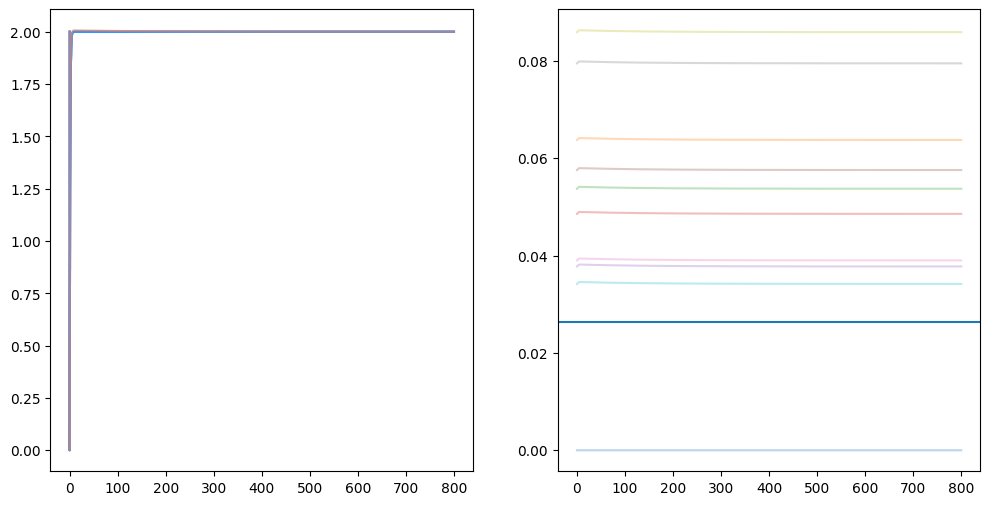

In [7]:
M = networks[0]["M"]
S = networks[0]["S"]

fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].plot(M.t, M.r[:-1].T, alpha=0.3, color='dodgerblue', linewidth=1.5)
axs[0].plot(M.t, M.r[-1].T, alpha=0.6, color='coral', linewidth=1.5)
# axs[0].set_ylim(1.8, 2.2)

axs[1].axhline(0.5/19)
axs[1].plot(S.t, S.w.T, alpha=0.3, linewidth=1.5)

plt.show()

### Single stimulations

In [8]:
tau_slows = np.arange(1.0, 2.01, 0.2) * second
delt_ws_random = zeros((tau_slows.size, w_grid.size))
delt_ws_sync = zeros_like(delt_ws_random)
delt_ws_gameplay = zeros_like(delt_ws_random)
for i, tau_slow in enumerate(tau_slows):
    for j, network in enumerate(networks):
        w_random = random_stimulation(network, tau_slow)
        delt_ws_random[i,j] = np.sum(network['S'].dw[0][(network['S'].t >= 800*second) & (network['S'].t <= 816*second)]) * LR * DT_RECORD
        w_sync = sync_stimulation(network, tau_slow)
        delt_ws_sync[i,j] = np.sum(network['S'].dw[0][(network['S'].t >= 800*second) & (network['S'].t <= 800.4*second)]) * LR * DT_RECORD
        # w_gameplay = gameplay_stimulation(network, tau_slow, t_stim=0.5*second)
        # delt_ws_random[i,j] = w_random - network["w_stim"]
        # delt_ws_sync[i,j] = w_sync - network["w_stim"]
        # delt_ws_gameplay[i,j] = w_gameplay - network["w_stim"]
        
       
        # delt_ws_sync[i,j] = w_sync - network["w_stim"]
        # delt_ws_gameplay[i,j] = w_gameplay - network["w_stim"]
        

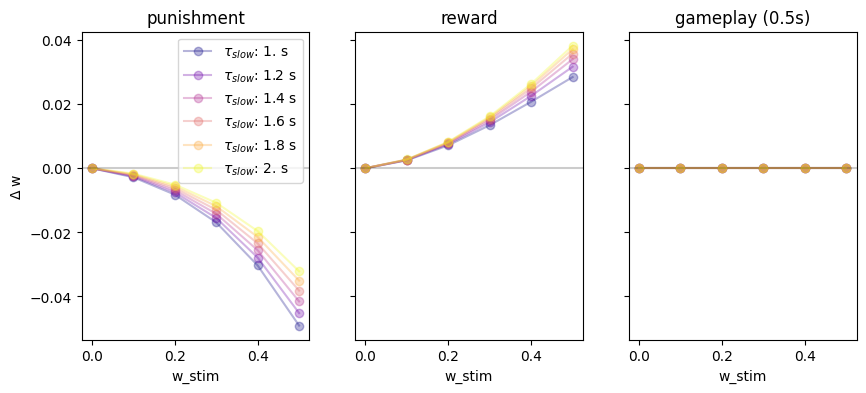

In [9]:
fig, axs = plt.subplots(1,3, figsize=(10,4), sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=tau_slows.min(), vmax=tau_slows.max())
for tau_slow, delta_w_random, delta_w_sync, delta_w_gameplay in zip(tau_slows, delt_ws_random, delt_ws_sync, delt_ws_gameplay):
    axs[0].plot(w_grid, delta_w_random, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')
    axs[1].plot(w_grid, delta_w_sync, '-o', color=cmap(norm(tau_slow)), alpha=0.3)
    axs[2].plot(w_grid, delta_w_gameplay, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')

for ax in axs:
    ax.set_xlabel('w_stim')
    ax.axhline(0, color='black', alpha=0.2)


axs[0].set_ylabel(r'$\Delta$ w')
axs[0].set_title('punishment')
axs[1].set_title('reward')
axs[2].set_title('gameplay (0.5s)')
axs[0].legend()

# axs[0].set_xlim(0, 0.0006)

plt.show()

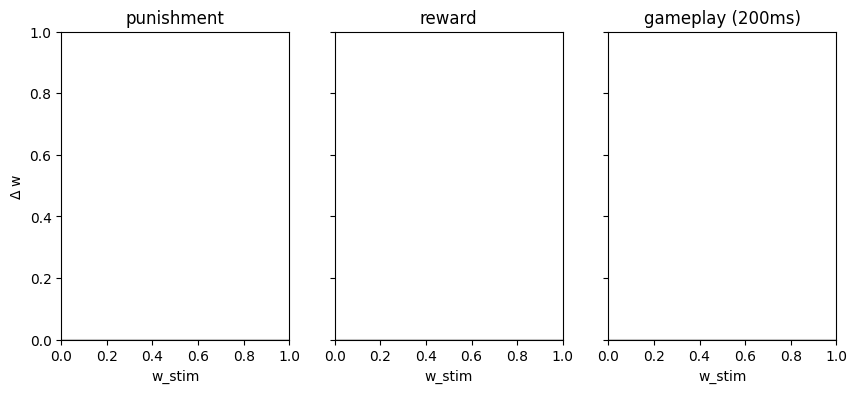

In [10]:
fig, axs = plt.subplots(1,3, figsize=(10,4), sharey=True)
A_LTD = 1

cmap = plt.cm.plasma
norm = plt.Normalize(vmin=tau_slows.min(), vmax=tau_slows.max())
for tau_slow, delta_w_random, delta_w_sync, delta_w_gameplay in zip(tau_slows, delt_ws_random, delt_ws_sync, delt_ws_gameplay):
    if isclose(tau_slow, 0.4*second, atol=1e-6*second):
        axs[0].plot(w_grid, -A_LTD*delta_w_random, '-o', color=cmap(norm(tau_slow)), alpha=0.3)
        axs[0].plot(w_grid, delta_w_sync, '-o', color=cmap(norm(tau_slow)), alpha=0.6)
        axs[2].plot(w_grid, delta_w_gameplay + A_LTD*delta_w_random, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')

for ax in axs:
    ax.set_xlabel('w_stim')
    ax.axhline(0, color='black', alpha=0.2)



axs[0].set_ylabel(r'$\Delta$ w')
axs[0].set_title('punishment')
axs[1].set_title('reward')
axs[2].set_title('gameplay (200ms)')
# axs[0].set_xlim(.01, 0.2)
# axs[1].set_ylim(-0.05, 0.05)
# axs[2].legend()



plt.show()

In [11]:
# R0 = 2
# tau_slow = 0.4
# alpha = 8e-5 * 2

# def r_slow_t(rj, rj0, t):
#     return rj - (rj - rj0) * np.exp(-t/tau_slow)

# def delta_w_S(rj, T_ext):
#     return T_ext * (rj - rj**2 / R0)

# def delta_w_T(rj, delta_rj, T_ext):
#     return tau_slow / R0 * (2 * rj * delta_rj * (1 - np.exp(- T_ext / tau_slow))
#                             - delta_rj**2 / R0 * (1 - np.exp(- 2 * T_ext / tau_slow)))
    
# def delta_w_pre_stim(ri, rj, w, f_stim, T_ext):
#     ri = R0 + f_stim
#     delta_rj = w * f_stim
#     rj = R0 + delta_rj
#     stim =  alpha * ri * rj * (delta_w_S(rj, T_ext) + delta_w_T(rj, delta_rj, T_ext))

#     r_slow = r_slow_t(rj, R0, T_ext)
#     ri = rj = R0 
#     delta_rj = R0 - r_slow
    
#     after_stim = alpha * ri * rj * (delta_w_S(rj, T_ext*3) + delta_w_T(rj, delta_rj, T_ext*3))
    
#     return stim + after_stim

# # def delta_w_post_stim(ri, rj, w, f_stim, T_ext):
# #     ri = R0
# #     delta_rj = f_stim
# #     rj = R0 + f_stim
# #     stim =  alpha * ri * rj * (delta_w_S(rj, T_ext) + delta_w_T(rj, delta_rj, T_ext))

# #     r_slow = r_slow_t(rj, R0, T_ext)
# #     ri = rj = R0 
# #     delta_rj = R0 - r_slow
    
# #     after_stim = alpha * ri * rj * (delta_w_S(rj, T_ext*3) + delta_w_T(rj, delta_rj, T_ext*3))
    
# #     return stim + after_stim

# ws = np.arange(0, 0.501, 0.1)
# results_p = np.zeros_like(ws)
# results_r = np.zeros_like(ws)

# for i, w in enumerate(ws):
#     results_p[i] = delta_w_pre_stim(2, 2, w, 5, 4)
#     results_r[i] = delta_w_pre_stim(2, 2, w, 25, 0.1)

In [12]:
def Z_term(tau_slow, T_ext):
    return tau_slow * (1 - np.exp(-T_ext / tau_slow))

def C3(z, T_ext, R0, u_ext, r_slow_0):
    return (z-T_ext) / R0 * np.pow(u_ext,3)

def C2(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z - 2 * T_ext) * np.pow(u_ext, 2)

def C1(z, T_ext, R0, u_ext, r_slow_0):
    return (3*z * R0 - T_ext * R0 - z * r_slow_0 / R0) * u_ext

def C0(z, T_ext, R0, u_ext, r_slow_0):
    return z * (np.pow(R0, 2) - r_slow_0)

def r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow):
    r_j_squared = np.pow((R0 + w * u_ext), 2)
    return r_j_squared - (r_j_squared - r_slow_0) * np.exp(- T_ext / tau_slow)

def delta_w(T_ext, R0, u_ext, r_slow_0, tau_slow, alpha, w):
    
    # stim 
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0 + u_ext
    trace_after_stim = r_slow_t(r_slow_0, T_ext, R0, u_ext, w, tau_slow)
    
    stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    # after_stim 
    u_ext = 0
    T_ext *= 3
    r_slow_0 = trace_after_stim
    
    
    z = Z_term(tau_slow, T_ext)
    c3 = C3(z, T_ext, R0, u_ext, r_slow_0)
    c2 = C2(z, T_ext, R0, u_ext, r_slow_0)
    c1 = C1(z, T_ext, R0, u_ext, r_slow_0)
    c0 = C0(z, T_ext, R0, u_ext, r_slow_0)
    
    ri = R0
    
    after_stim = alpha * ri * (c3 * np.pow(w, 3) + c2 * np.pow(w, 2) + c1 * w + c0)
    
    return stim + after_stim

R_NULL = 2
ALPHA = LR
R_SLOW_NULL = R_NULL**2

tau_slow = 1.8

T_EXT = 0.1
U_EXT = 25
results_r = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, w_grid)

T_EXT = 4
U_EXT = 5
results_p = delta_w(T_EXT, R_NULL, U_EXT, R_SLOW_NULL, tau_slow, ALPHA, w_grid)

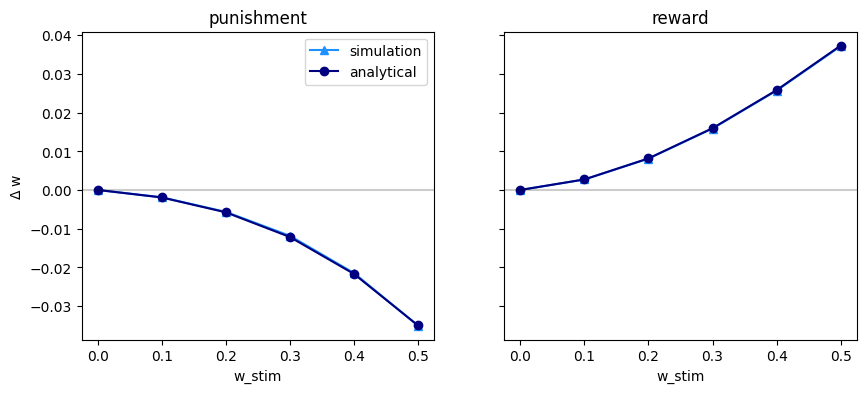

In [13]:
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)

for tau_slow, delta_w_random, delta_w_sync, delta_w_gameplay in zip(tau_slows, delt_ws_random, delt_ws_sync, delt_ws_gameplay):
    if isclose(tau_slow, 1.8*second, atol=1e-6*second):
        axs[0].plot(w_grid, delta_w_random, color='dodgerblue', label='simulation', marker='^')
        axs[0].plot(w_grid, results_p,  color='navy', label='analytical', marker='o')
        axs[1].plot(w_grid, delta_w_sync,  color='dodgerblue', marker='^')
        axs[1].plot(w_grid, results_r, color='navy', marker='o')

for ax in axs:
    ax.set_xlabel('w_stim')
    ax.axhline(0, color='black', alpha=0.2)



axs[0].set_ylabel(r'$\Delta$ w')
axs[0].legend()
axs[0].set_title('punishment')
axs[1].set_title('reward')
# axs[0].set_xlim(.01, 0.2)
# axs[1].set_ylim(-0.05, 0.05)
# axs[2].legend()



plt.show()

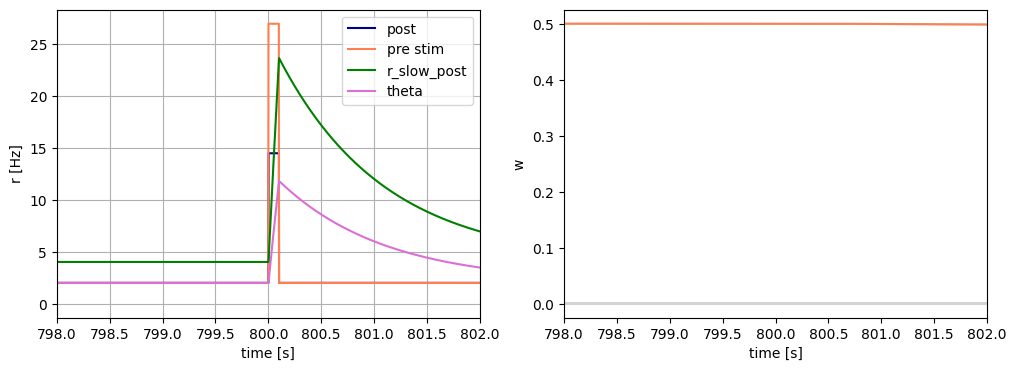

In [14]:
fig, axs = plt.subplots(1,2, figsize=(12,4),sharex=True)
network = networks[-1]
network["net"].restore("post_sync_1.00")
M = network["M"]
S = network["S"]

axs[0].plot(M.t, M.r[-1].T, label='post', color='darkblue')
axs[0].plot(M.t, M.r[0].T, label='pre stim', color='coral')
axs[0].plot(M.t, M.r_slow[-1].T, label='r_slow_post', color='green')
axs[0].plot(S.t, S.theta[0].T, label='theta', color='orchid')
axs[0].legend()
axs[1].plot(S.t, S.w.T, alpha=1, linewidth=1.5, color='lightgray')
axs[1].plot(S.t, S.w[0].T, alpha=1, linewidth=1.5, color='coral')


for ax in axs:
    ax.set_xlabel('time [s]')
    
axs[1].set_xlim(798, 802)
axs[0].grid(True)
axs[0].set_ylabel('r [Hz]')
axs[1].set_ylabel('w')

plt.show()

### Paired reward and gameplay stimulations

In [15]:
tau_slows = np.arange(0.5, 2.01, 0.5) * second
delt_ws_random = zeros((tau_slows.size, w_grid.size))
delt_ws_sync = zeros_like(delt_ws_random)
delt_ws_gameplay = zeros_like(delt_ws_random)
delt_ws_gameplay_2 = zeros_like(delt_ws_random)
for i, tau_slow in enumerate(tau_slows):
    for j, network in enumerate(networks):
        # w_random = random_stimulation(network, tau_slow)
        
        t_gameplay_stim=0.3*second
        
        _ = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, t_after=0*second, store=False)
        _ = sync_stimulation(network, tau_slow, t_after=0*second, restore=False, store=False)
        w_gameplay_sync_gameplay = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, restore=False)
        
        _ = sync_stimulation(network, tau_slow, t_after=0*second, store=False)
        w_sync_gameplay = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, restore=False)
        

        _ = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, t_after=0*second, store=False)
        w_gameplay_sync = sync_stimulation(network, tau_slow, restore=False)
        
        # _ = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, t_after=0*second, store=False)
        # w_gameplay_random = random_stimulation(network, tau_slow, restore=False)

        
        delt_ws_random[i,j] = w_gameplay_sync_gameplay - network["w_stim"]
        delt_ws_sync[i,j] = w_sync_gameplay - network["w_stim"]
        delt_ws_gameplay[i,j] = w_gameplay_sync - network["w_stim"]
        # delt_ws_gameplay_2[i,j] = w_gameplay_random - network["w_stim"]

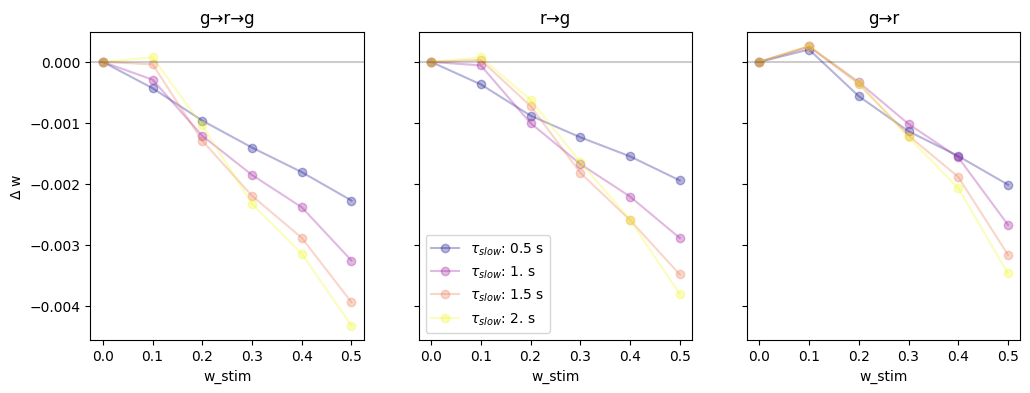

In [16]:
fig, axs = plt.subplots(1,3, figsize=(12,4), sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=tau_slows.min(), vmax=tau_slows.max())
for tau_slow, delta_w_random, delta_w_sync, delta_w_gameplay in zip(tau_slows, delt_ws_random, delt_ws_sync, delt_ws_gameplay):
    axs[0].plot(w_grid, delta_w_random, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')
    axs[1].plot(w_grid, delta_w_sync, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')
    axs[2].plot(w_grid, delta_w_gameplay, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')
    # axs[3].plot(w_grid, delt_ws_gameplay_2, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')

for ax in axs:
    ax.set_xlabel('w_stim')
    ax.axhline(0, color='black', alpha=0.2)


axs[0].set_ylabel(r'$\Delta$ w')
axs[0].set_title('g→r→g')
axs[1].set_title('r→g')
axs[2].set_title('g→r')
axs[1].legend(loc='lower left')

# axs[0].set_ylim(-0.02, 0.02)

plt.show()

In [17]:
raise KeyboardInterrupt

KeyboardInterrupt: 

### Paired gameplay and punishment stimulation

In [ ]:
tau_slows = np.arange(0.4, 1.61, 0.2) * second
delt_ws_random = zeros((tau_slows.size, w_grid.size))
delt_ws_sync = zeros_like(delt_ws_random)
delt_ws_gameplay = zeros_like(delt_ws_random)
for i, tau_slow in enumerate(tau_slows):
    for j, network in enumerate(networks):
        # w_random = random_stimulation(network, tau_slow)
        
        t_gameplay_stim=1*second
        
        _ = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, t_after=0*second, store=False)
        _ = sync_stimulation(network, tau_slow, t_after=0*second, restore=False, store=False)
        w_gameplay_sync_gameplay = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, restore=False)
        
        _ = sync_stimulation(network, tau_slow, t_after=0*second, store=False)
        w_sync_gameplay = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, restore=False)
        

        _ = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, t_after=0*second, store=False)
        w_gameplay_sync = sync_stimulation(network, tau_slow, restore=False)

        
        delt_ws_random[i,j] = w_gameplay_sync_gameplay - network["w_stim"]
        delt_ws_sync[i,j] = w_sync_gameplay - network["w_stim"]
        delt_ws_gameplay[i,j] = w_gameplay_sync - network["w_stim"]

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(10,4), sharey=True)
A_LTD = 5

cmap = plt.cm.plasma
norm = plt.Normalize(vmin=tau_slows.min(), vmax=tau_slows.max())
for tau_slow, delta_w_random, delta_w_sync, delta_w_gameplay in zip(tau_slows, delt_ws_random, delt_ws_sync, delt_ws_gameplay):
    if isclose(tau_slow, 0.4*second, atol=1e-6*second):
        axs[0].plot(w_grid, -A_LTD*delta_w_random, '-o', color=cmap(norm(tau_slow)), alpha=0.3)
        axs[0].plot(w_grid, delta_w_sync, '-o', color=cmap(norm(tau_slow)), alpha=0.6)
        axs[2].plot(w_grid, delta_w_gameplay, '-o', color=cmap(norm(tau_slow)), alpha=0.3, label=r'$\tau_{slow}$: ' + f'{tau_slow}')

for ax in axs:
    ax.set_xlabel('w_stim')
    ax.axhline(0, color='black', alpha=0.2)



axs[0].set_ylabel(r'$\Delta$ w')
axs[0].set_title('punishment')
axs[1].set_title('reward')
axs[2].set_title('gameplay (200ms)')
axs[0].set_xlim(.01, 0.15)
axs[1].set_ylim(-0.1, 0.4)
axs[2].legend()



plt.show()

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,4),sharex=True)
network = networks[-1]
network["net"].restore("post_sync_0.80")
M = network["M"]
S = network["S"]

axs[0].plot(M.t, M.r[-1].T, label='post', color='darkblue')
axs[0].plot(M.t, M.r[0].T, label='pre stim', color='coral')
axs[0].plot(S.t, S.theta[0].T, label='theta', color='orchid')
axs[0].legend()
axs[1].plot(S.t, S.w.T, alpha=1, linewidth=1.5, color='lightgray')
axs[1].plot(S.t, S.w[0].T, alpha=1, linewidth=1.5, color='coral')


for ax in axs:
    ax.set_xlabel('time [s]')
    
axs[1].set_xlim(798, 808)
axs[0].set_ylabel('r [Hz]')
axs[1].set_ylabel('w')

plt.show()

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,4),sharex=True)
network = networks[-3]
network["net"].restore("post_sync_0.80")
M = network["M"]
S = network["S"]

network["net"].restore("init_5_min")
network['synapses'].Tau_W = 100*ms
for _ in range(30):
    _ = gameplay_stimulation(network, tau_slow, t_stim=t_gameplay_stim, t_after=0*second, store=False, restore=False)
    _ = sync_stimulation(network, tau_slow, t_after=0*second, restore=False, store=False)
    w_gameplay_sync_gameplay = gameplay_stimulation(network, tau_slow, t_after=1*second, t_stim=t_gameplay_stim, restore=False)
    
w_gameplay_sync_gameplay = gameplay_stimulation(network, tau_slow, t_after=10*second, t_stim=t_gameplay_stim, restore=False)    

    

axs[0].plot(M.t, M.r[-1].T, label='post', color='darkblue')
axs[0].plot(M.t, M.r[0].T, label='pre stim', color='coral')
axs[0].plot(S.t, S.theta[0].T, label='theta', color='orchid')
axs[0].legend()
axs[1].plot(S.t, S.w.T, alpha=1, linewidth=1.5, color='lightgray')
axs[1].plot(S.t, S.w[0].T, alpha=1, linewidth=1.5, color='coral')


for ax in axs:
    ax.set_xlabel('time [s]')

axs[1].set_xlim(xmin=780)
axs[0].set_ylabel('r [Hz]')
axs[1].set_ylabel('w')
plt.show()